### Important imports

In [2]:
import numpy as np 
import torch
from torch.utils.data import Dataset,DataLoader
import glob
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt 
import cv2
from itertools import islice


### Reading the Images & Reshaping


In [20]:
pneumonia  = []
path = './chest_xray/train/PNEUMONIA/*.jpeg' 

#glob allows to walk through a directory 
#cv2 is used for reading images, specially multichannel ones(RGB)
for f in islice(glob.iglob(path), 200):
    img = cv2.imread(f)
    img = cv2.resize(img,(256,256))
    b,g,r = cv2.split(img) #reordering the rgb
    img = cv2.merge([r,g,b]) 
    pneumonia.append(img)


In [21]:
healthy = []
path = './chest_xray/train/NORMAL/*.jpeg'

for f in islice(glob.iglob(path), 200):
    img = cv2.imread(f)
    img = cv2.resize(img,(256,256))
    b,g,r = cv2.split(img)
    img = cv2.merge([r,g,b]) 
    healthy.append(img)

In [47]:
all_imgs = np.concatenate((healthy,pneumonia))


### Visualizing the Images

In [ ]:
#matplotlib is used for visuzaling imgs

def show_random_imgs(healthy,pneumonia,img_num):
    
    healthy_img = healthy[np.random.choice(healthy.shape[0],img_num, replace = False)]
    pneumonia_imgs = pneumonia[np.random.choice(pneumonia.shape[0],img_num, replace = False)]
    plt.figure(figsize=(15,9))

    for i in range(img_num):
        plt.subplot(1,img_num, i+1)
        plt.title('Healthy')
        plt.imshow(healthy_img[i])

    plt.figure(figsize=(15,9))
    for i in range(img_num):
        plt.subplot(1,img_num, i+1)
        plt.title('Pneumonia')
        plt.imshow(pneumonia_imgs[i])

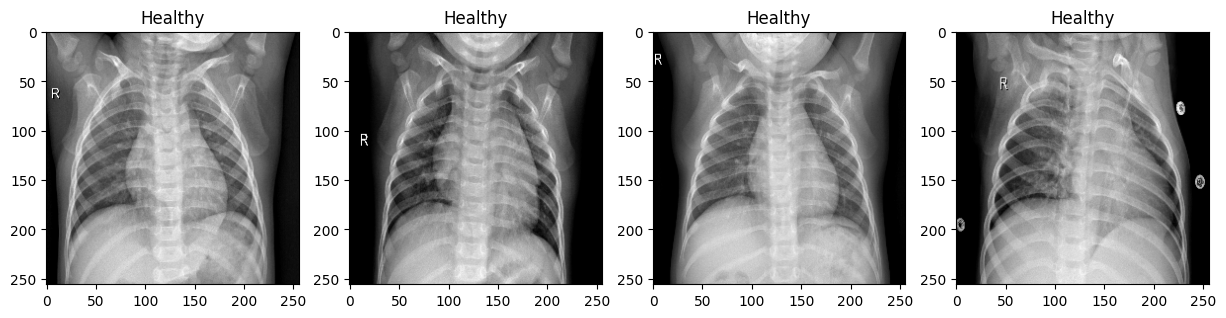

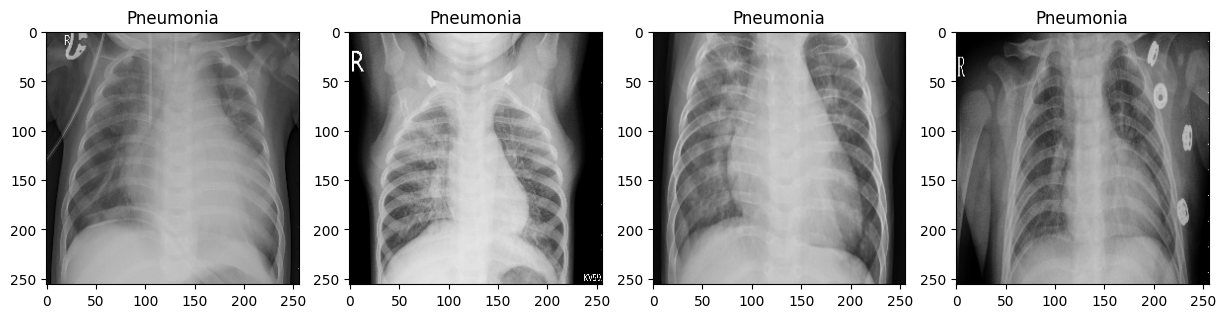

In [55]:
healthy = np.array(healthy)
pneumonia = np.array(pneumonia)

show_random_imgs(healthy,pneumonia,4)

### Dataset Class

In [ ]:
class MRI(Dataset):
    def __init__(self): #loads all the data 
        pneumonia  = []
        healthy = []
        path = './chest_xray/train/PNEUMONIA/*.jpeg' 

        #glob allows to walk through a directory 
        #cv2 is used for reading images, specially multichannel ones(RGB)
        for f in islice(glob.iglob(path), 200):
            img = cv2.imread(f)
            img = cv2.resize(img,(256,256))
            b,g,r = cv2.split(img) #reordering the rgb
            img = cv2.merge([r,g,b]) 
            pneumonia.append(img)

        path = './chest_xray/train/NORMAL/*.jpeg'
        for f in islice(glob.iglob(path), 200):
            img = cv2.imread(f)
            img = cv2.resize(img,(256,256))
            b,g,r = cv2.split(img)
            img = cv2.merge([r,g,b]) 
            healthy.append(img)
        
        #images
        healthy = np.array(healthy, dtype=np.float32)
        pneumonia = np.array(pneumonia, dtype=np.float32)

        #labels
        pneumonia_label = np.ones(pneumonia.shape[0],dtype = np.float32)
        healthy_label = np.zeros(healthy.shape[0],dtype = np.float32)

        self.images = np.concatenate((pneumonia,healthy),axis = 0)
        self.labels = np.concatenate((pneumonia_label,healthy_label),axis = 0)

    def __getitem__(self,index):
        sample = {'image':self.images[index],'label':self.labels[index]}
        return sample
    
    def __len__(self):
        return self.images.shape[0]
    
    def normalize(self):
        self.images = self.images/256.0
    
